In [ ]:
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Copy the zip file from My Drive to the local Colab storage
# Note: Copying it locally first makes reading images during training MUCH faster!
!cp "/content/drive/MyDrive/anime_faces.zip" "/content/anime_faces.zip"

# 3. Unzip the dataset into a new folder
# The '-q' flag keeps it quiet so it doesn't crash your browser by printing thousands of file names
!unzip -q "/content/anime_faces.zip" -d "/content/"

print("Dataset copied and unzipped successfully!")

Mounted at /content/drive
Dataset copied and unzipped successfully!


In [ ]:
# installation cell
!pip install piq kornia onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 20.4 MB/s eta 0:00:00


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from piq import ssim as ssim_func
import os
import shutil
from tqdm import tqdm
from torch.utils.data import TensorDataset
import kornia
from torch.nn.utils import spectral_norm

In [ ]:
# HYPERPARAMETERS
total_epochs = 25
warmup_epochs = 25
beta_initial = 0.0
beta_target = 0.05
latent_dim = 16
learning_rate_G = 5e-4
learning_rate_D = 5e-4
adv_weight = 0
batch_size = 64

In [ ]:
# 1. Basic transformation
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

# 2. Point to your image folder
dataset = datasets.ImageFolder(root='./anime_faces/train', transform=transform)
val_dataset = datasets.ImageFolder(root='./anime_faces/val',transform=transform)
# 3. Create the DataLoader
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset,batch_size=batch_size,num_workers=os.cpu_count())

# 4. Test it: Pull one batch of images
images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")

Batch shape: torch.Size([64, 3, 48, 48])


In [ ]:
class ResDownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResDownBlock, self).__init__()

        # Main path
        self.main = nn.Sequential(
            # Downsample
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            # Refine
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels)
        )

        # Skip path
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2),
            nn.BatchNorm2d(out_channels)
        )

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(self.main(x) + self.shortcut(x))

class ResUpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResUpBlock, self).__init__()

        # Main path
        self.main = nn.Sequential(
            # Upsample
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            # Refine
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )

        # Skip Path
        self.shortcut = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        # Element-wise addition
        return self.act(self.main(x) + self.shortcut(x))



class DiscResDownBlock(nn.Module):
  def __init__(self,in_channels,out_channels):
    super(DiscResDownBlock, self).__init__()

    # main path
    self.main = nn.Sequential(
        spectral_norm(nn.Conv2d(in_channels,out_channels,kernel_size=4,stride=2,padding=1)),
        nn.LeakyReLU(negative_slope=0.2,inplace=True),
        spectral_norm(nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1)),
    )

    # skip path
    self.shortcut = nn.Sequential(
        spectral_norm(nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=2)),
    )

    self.act = nn.LeakyReLU(negative_slope=0.2,inplace=True)

  def forward(self,x):
    return self.act(self.main(x)+self.shortcut(x))

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator,self).__init__()

        self.net = nn.Sequential(
            # 3x48x48 to 32x24x24
            DiscResDownBlock(3,32),

            # 32x24x24 to 64x12x12
            DiscResDownBlock(32,64),

            # 64x12x12 to 128x6x6
            DiscResDownBlock(64,128),

            nn.Flatten(),

            nn.Linear(128*6*6,1),
        )

    def forward(self,x):
        return self.net(x)


In [ ]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(BetaVAE, self).__init__()

        # Encoder: 3x48x48 -> Latent Space
        self.encoder = nn.Sequential(

            # 3x48x48 to 32x24x24
            ResDownBlock(3,32),

            # 32x24x24 to 64x12x12
            ResDownBlock(32,64),

            # 64x12x12 to 128x6x6
            ResDownBlock(64,128),

            # 128x6x6 to 256x3x3
            ResDownBlock(128,256),

            nn.Flatten()
        )

        # Latent vectors (mu and log_var)
        # 256 * 3 * 3 = 2304
        self.fc_mu = nn.Sequential(
            nn.Linear(2304,512),
            nn.ReLU(),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Linear(128,latent_dim)
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(2304,512),
            nn.ReLU(),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Linear(128,latent_dim)
        )
        # Decoder: Latent Space -> 3x48x48
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(128, 512),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(512,2304),
        )


        # self.fc_mu = nn.Linear(2304,latent_dim)
        # self.fc_logvar = nn.Linear(2304,latent_dim)
        # self.decoder_input = nn.Linear(latent_dim,2304)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 3, 3)),

            # 256x3x3 to 128x6x6
            ResUpBlock(256,128),

            # 128x6x6 to 64x12x12
            ResUpBlock(128,64),

            # 64x12x12 to 32x24x24
            ResUpBlock(64,32),

            # 32x24x24 to 3x48x48 (Final layer no skip connection needed)
            nn.Upsample(scale_factor=2, mode='nearest'), # 48x48
            # Upsample
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.2,inplace=True),
            # Refine
            nn.Conv2d(32,3,kernel_size=3,padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """The Reparameterization Trick: z = mu + std * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar


In [ ]:
# --- The Beta-VAE Loss Function ---
def loss_function(recon_x, x, mu, logvar, beta=4.0,z=0.5):
    # Structural Loss (SSIM)
    ssim_val = ssim_func(recon_x, x, data_range=1.0, reduction='mean')
    ssim_loss = (1-ssim_val)

    # L1 loss on lab
    lab_recon = kornia.color.rgb_to_lab(recon_x)
    lab_x = kornia.color.rgb_to_lab(x)

    scale_tensor = torch.tensor([100.0, 128.0, 128.0], device=x.device).view(1, 3, 1, 1)
    lab_recon_norm = lab_recon / scale_tensor
    lab_x_norm = lab_x / scale_tensor

    l1_loss = F.l1_loss(lab_recon_norm, lab_x_norm, reduction='mean')

    # Reconstruction Loss SSIM + z*L1
    reconstruction_loss = ssim_loss + z * l1_loss

    # 2. KL Divergence
    kld_element = 1 + logvar - mu.pow(2) - logvar.exp()
    kld_loss = -0.5 * torch.mean(torch.sum(kld_element, dim=1)) / latent_dim

    # Total loss
    total_loss = reconstruction_loss + (beta * kld_loss)
    return total_loss, reconstruction_loss, kld_loss

In [ ]:
adv_loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
model = BetaVAE(latent_dim=latent_dim).to(device)
discriminator = Discriminator().to(device)

cuda


In [ ]:
optimizer_G = torch.optim.Adam(model.parameters(), lr=learning_rate_G)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=learning_rate_D)

scheduler_G = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_G, mode='min', factor=0.75, patience=3
)

In [ ]:
def train_epoch(model, discriminator, dataloader, optimizer_G, optimizer_D, device, beta_weight=4.0):
    model.train()
    discriminator.train()

    # Sum of losses
    running_g_loss = 0.0
    running_d_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    progress_bar = tqdm(dataloader, total=len(dataloader), desc="Training", leave=False)

    for images, _ in progress_bar:
        images = images.to(device)
        batch_size = images.size(0)

        # Labels for Discriminator
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ================================Train discriminator================================
        # optimizer_D.zero_grad()

        # # FORWARD PASS 1: Generate fakes purely to train the discriminator
        # recon_batch_d, _, _ = model(images)

        # real_preds = discriminator(images)
        # d_loss_real = adv_loss_fn(real_preds, real_labels)

        # # .detach() prevents D's gradients from flowing back into the Generator
        # fake_preds = discriminator(recon_batch_d.detach())
        # d_loss_fake = adv_loss_fn(fake_preds, fake_labels)

        # d_loss = (d_loss_real + d_loss_fake) / 2
        # d_loss.backward()
        # optimizer_D.step()

        # DUMMY LOSS AS ADVERSARIAL NETWORK IS OFF FOR NOW
        d_loss = torch.tensor(0.0)

        # ================================Train Generator====================================

        optimizer_G.zero_grad()

        # FORWARD PASS 2: Fresh pass to build a clean computational graph for the Generator
        recon_batch_g, mu, logvar = model(images)

        # standard loss (calculated on the FRESH batch)
        vae_loss, batch_rec, batch_kld = loss_function(recon_batch_g, images, mu, logvar, beta=beta_weight)

        # adv loss (calculated on the FRESH batch)
        fake_preds_for_G = discriminator(recon_batch_g)
        g_adv_loss = adv_loss_fn(fake_preds_for_G, real_labels)

        # total loss (Assuming adv_weight is defined globally in your script)
        g_loss = vae_loss + adv_weight * g_adv_loss

        # Backward pass
        g_loss.backward()
        optimizer_G.step()

        # --- Tracking ---
        running_g_loss += g_loss.item() * batch_size
        running_d_loss += d_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

        progress_bar.set_postfix({
            "G_Loss": f"{g_loss.item():.3f}",
            "D_Loss": f"{d_loss.item():.3f}",
            "Rec": f"{batch_rec.item():.3f}"
        })

    dataset_size = len(dataloader.dataset)
    return running_g_loss/dataset_size, running_d_loss/dataset_size, running_rec/dataset_size, running_kld/dataset_size

In [ ]:
def save_checkpoint(state_dict, is_best, folder="./checkpoints", filename="checkpoint.pth"):
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)

    # Save the latest epoch
    torch.save(state_dict, filepath)

    # If it's the best so far, overwrite the best model file
    if is_best:
        best_filepath = os.path.join(folder, "model_best.pth")
        shutil.copyfile(filepath, best_filepath)
        # Updated key here to match the new payload!
        print(f"--> ✨ New best model saved! Val Loss: {state_dict['best_val_loss']:.4f}")

In [ ]:
# --- Validation Function ---
@torch.no_grad()
def validate_epoch(model, discriminator, dataloader, device, beta_weight=4.0):
    """Runs a single pass over the validation set without tracking gradients."""
    model.eval()
    discriminator.eval()

    running_g_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    for images, _ in dataloader:
        images = images.to(device)
        batch_size = images.size(0)
        real_labels = torch.ones(batch_size,1).to(device)

        # Forward pass only
        recon_batch, mu, logvar = model(images)
        vae_loss, batch_rec, batch_kld = loss_function(recon_batch, images, mu, logvar, beta=beta_weight)

        # calc how well G fooled D
        fake_preds_for_G = discriminator(recon_batch)
        g_adv_loss = adv_loss_fn(fake_preds_for_G,real_labels)

        g_loss = vae_loss + adv_weight*g_adv_loss

        # Accumulate sums
        running_g_loss += g_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

    dataset_size = len(dataloader.dataset)
    return running_g_loss / dataset_size, running_rec / dataset_size, running_kld / dataset_size

In [ ]:
# checkpoint_path = "./checkpoints/checkpoint.pth"
checkpoint_path = ""

# --- Setup & Nomenclature ---
best_val_loss = float('inf')

start_epoch = 1

# Clean history tracking, now actually tracking validation
history = {
    'train_g_loss': [], 'train_d_loss': [], 'train_rec': [], 'train_kld': [],
    'val_g_loss': [], 'val_rec': [], 'val_kld': [],
    'learning_rate': []
}

# Check if the file actually exists
if os.path.exists(checkpoint_path):
    print(f"Found checkpoint at {checkpoint_path}. Loading...")

    # Load the model
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Restore the model and optimizer memory
    model.load_state_dict(checkpoint['model_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
    scheduler_G.load_state_dict(checkpoint['scheduler_G_state_dict'])

    # Restore our trackers
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    history = checkpoint['history']

    print(f"Resuming training from Epoch {start_epoch}")
else:
    print("No checkpoint found. Starting training from scratch.")

No checkpoint found. Starting training from scratch.


In [ ]:
def cache_dataset_vram(dataset, device):
    """Load all images directly into VRAM (GPU memory) as a single tensor batch."""

    # pin_memory=True speeds up the initial transfer from CPU to GPU
    loader = DataLoader(dataset, batch_size=256, num_workers=os.cpu_count(), pin_memory=True)
    images_list, labels_list = [], []

    for imgs, lbls in tqdm(loader, desc=f"Caching to VRAM ({device})"):
        # Move data to the GPU immediately
        # non_blocking=True allows asynchronous data transfers, speeding up the process
        images_list.append(imgs.to(device, non_blocking=True))
        labels_list.append(lbls.to(device, non_blocking=True))

    return TensorDataset(torch.cat(images_list), torch.cat(labels_list))

# --- How to use it ---
# # Make sure 'device' is defined before calling this!
print("Caching train set to VRAM...")
train_cached_vram = cache_dataset_vram(dataset, device)
print("Caching val set to VRAM...")
val_cached_vram   = cache_dataset_vram(val_dataset, device)

# # Replace the loaders with VRAM-based loaders
# # IMPORTANT: num_workers MUST be 0 here because multiprocessing cannot handle GPU tensors
train_loader = DataLoader(train_cached_vram, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_cached_vram,   batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Done. Train: {len(train_cached_vram)} | Val: {len(val_cached_vram)}")

Caching train set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 245/245 [00:32<00:00,  7.56it/s]


Caching val set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 4/4 [00:00<00:00,  5.16it/s]

Done. Train: 62541 | Val: 1024


In [ ]:
print(f"Starting training on device: {device}")

for epoch in range(start_epoch, total_epochs + 1):
    # Step function for Beta Warmup
    current_beta = min(beta_target, beta_initial + (beta_target / warmup_epochs) * (epoch - 1))
    current_lr = optimizer_G.param_groups[0]['lr']

    print(f"Epoch [{epoch}/{total_epochs}] | Beta: {current_beta:.1f} | LR: {current_lr}")

    # 1. Run one training epoch
    train_g, train_d, train_rec, train_kld = train_epoch(
        model,
        discriminator,
        train_loader,
        optimizer_G,
        optimizer_D,
        device,
        current_beta
    )

    # 2. Run one validation epoch
    val_g, val_rec, val_kld = validate_epoch(
        model,
        discriminator,
        val_loader,
        device,
        current_beta
    )

    # 3. Record history
    history['train_g_loss'].append(train_g)
    history['train_d_loss'].append(train_d)
    history['train_rec'].append(train_rec)
    history['train_kld'].append(train_kld)

    history['val_g_loss'].append(val_g)
    history['val_rec'].append(val_rec)
    history['val_kld'].append(val_kld)
    history['learning_rate'].append(current_lr)

    # 4. Print logs
    print(f"  Train -> G-Loss: {train_g:.4f} | D-Loss: {train_d:.4f} (Rec: {train_rec:.4f}, KLD: {train_kld:.4f})")
    print(f"  Val   -> G-Loss: {val_g:.4f} (Rec: {val_rec:.4f}, KLD: {val_kld:.4f})")


    # 5. Check if this is the best model (Evaluating based on VALIDATION loss)
    is_best = val_g < best_val_loss
    if is_best:
        best_val_loss = val_g

# 6. Save Checkpoint payload with the new Discriminator variables
    checkpoint_payload = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        'scheduler_G_state_dict': scheduler_G.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history,
    }
    save_checkpoint(checkpoint_payload, is_best)

    scheduler_G.step(val_g)

Starting training on device: cuda
Epoch [1/25] | Beta: 0.0 | LR: 0.0005


  Train -> G-Loss: 0.5909 | D-Loss: 0.0000 (Rec: 0.5909, KLD: 14.0257)
  Val   -> G-Loss: 0.5591 (Rec: 0.5591, KLD: 18.3631)
--> ✨ New best model saved! Val Loss: 0.5591
Epoch [2/25] | Beta: 0.0 | LR: 0.0005


  Train -> G-Loss: 0.5306 | D-Loss: 0.0000 (Rec: 0.5239, KLD: 3.3453)
  Val   -> G-Loss: 0.5476 (Rec: 0.5414, KLD: 3.1153)
--> ✨ New best model saved! Val Loss: 0.5476
Epoch [3/25] | Beta: 0.0 | LR: 0.0005


  Train -> G-Loss: 0.5225 | D-Loss: 0.0000 (Rec: 0.5115, KLD: 2.7294)
  Val   -> G-Loss: 0.5427 (Rec: 0.5313, KLD: 2.8329)
--> ✨ New best model saved! Val Loss: 0.5427
Epoch [4/25] | Beta: 0.0 | LR: 0.0005


  Train -> G-Loss: 0.5198 | D-Loss: 0.0000 (Rec: 0.5046, KLD: 2.5230)
  Val   -> G-Loss: 0.5451 (Rec: 0.5307, KLD: 2.4002)
Epoch [5/25] | Beta: 0.0 | LR: 0.0005


...

  Train -> G-Loss: 0.5348 | D-Loss: 0.0000 (Rec: 0.4657, KLD: 1.7260)
  Val   -> G-Loss: 0.5776 (Rec: 0.5092, KLD: 1.7099)
Epoch [22/25] | Beta: 0.0 | LR: 0.00015820312500000003


  Train -> G-Loss: 0.5373 | D-Loss: 0.0000 (Rec: 0.4658, KLD: 1.7023)
  Val   -> G-Loss: 0.5798 (Rec: 0.5085, KLD: 1.6991)
Epoch [23/25] | Beta: 0.0 | LR: 0.00015820312500000003


  Train -> G-Loss: 0.5398 | D-Loss: 0.0000 (Rec: 0.4658, KLD: 1.6811)
  Val   -> G-Loss: 0.5837 (Rec: 0.5107, KLD: 1.6586)
Epoch [24/25] | Beta: 0.0 | LR: 0.00011865234375000002


  Train -> G-Loss: 0.5404 | D-Loss: 0.0000 (Rec: 0.4637, KLD: 1.6662)
  Val   -> G-Loss: 0.5846 (Rec: 0.5085, KLD: 1.6530)
Epoch [25/25] | Beta: 0.0 | LR: 0.00011865234375000002


  Train -> G-Loss: 0.5427 | D-Loss: 0.0000 (Rec: 0.4637, KLD: 1.6455)
  Val   -> G-Loss: 0.5880 (Rec: 0.5111, KLD: 1.6034)


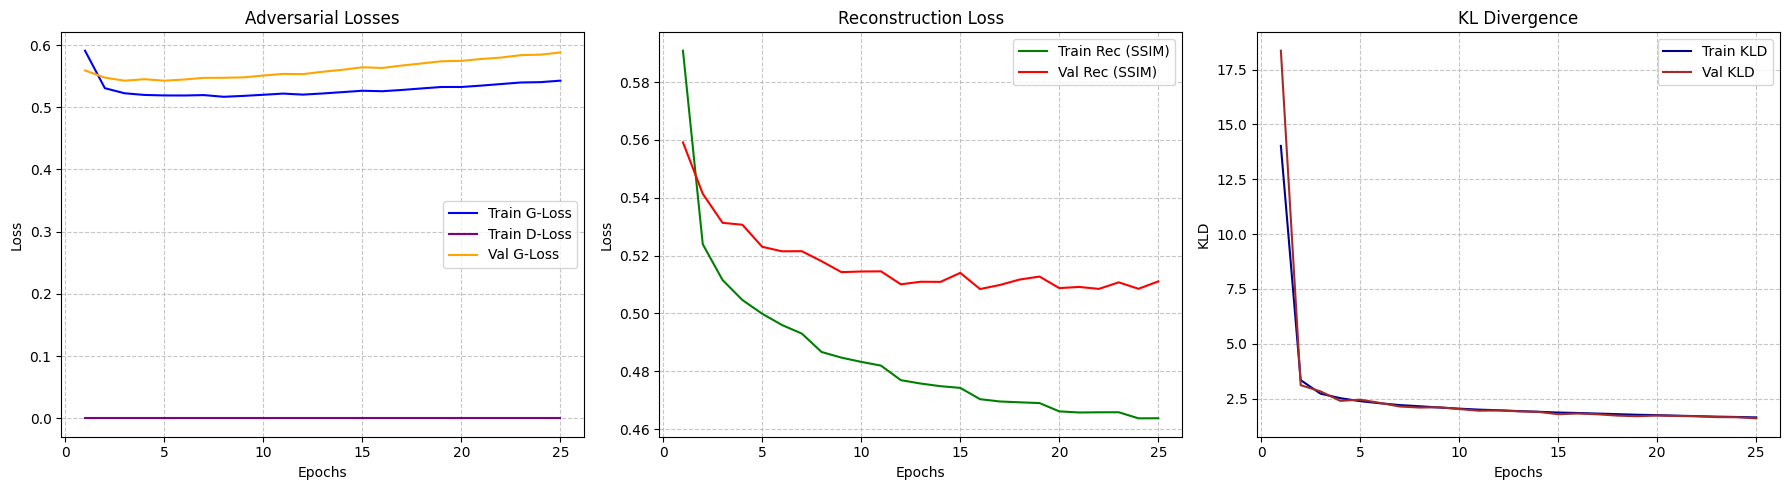

In [ ]:
def plot_training_curves(history):
    # Determine the number of epochs trained so far
    epochs = range(1, len(history['train_g_loss']) + 1)

    # Create a 1x3 grid for our plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- 1. GAN Losses (Generator vs Discriminator) ---
    axes[0].plot(epochs, history['train_g_loss'], label='Train G-Loss', color='blue')
    axes[0].plot(epochs, history['train_d_loss'], label='Train D-Loss', color='purple')
    axes[0].plot(epochs, history['val_g_loss'], label='Val G-Loss', color='orange')
    axes[0].set_title('Adversarial Losses')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- 2. Reconstruction Loss ---
    axes[1].plot(epochs, history['train_rec'], label='Train Rec (SSIM)', color='green')
    axes[1].plot(epochs, history['val_rec'], label='Val Rec (SSIM)', color='red')
    axes[1].set_title('Reconstruction Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # --- 3. KL Divergence ---
    axes[2].plot(epochs, history['train_kld'], label='Train KLD', color='darkblue')
    axes[2].plot(epochs, history['val_kld'], label='Val KLD', color='brown')
    axes[2].set_title('KL Divergence')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('KLD')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the function to display the plots
plot_training_curves(history)

In [ ]:
model.load_state_dict(torch.load('./checkpoints/checkpoint.pth', map_location=device)['model_state_dict'])
model.eval()

BetaVAE(
  (encoder): Sequential(
    (0): ResDownBlock(
      (main): Sequential(
        (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): ResDownBlock(
      (main): Sequential(
        (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_

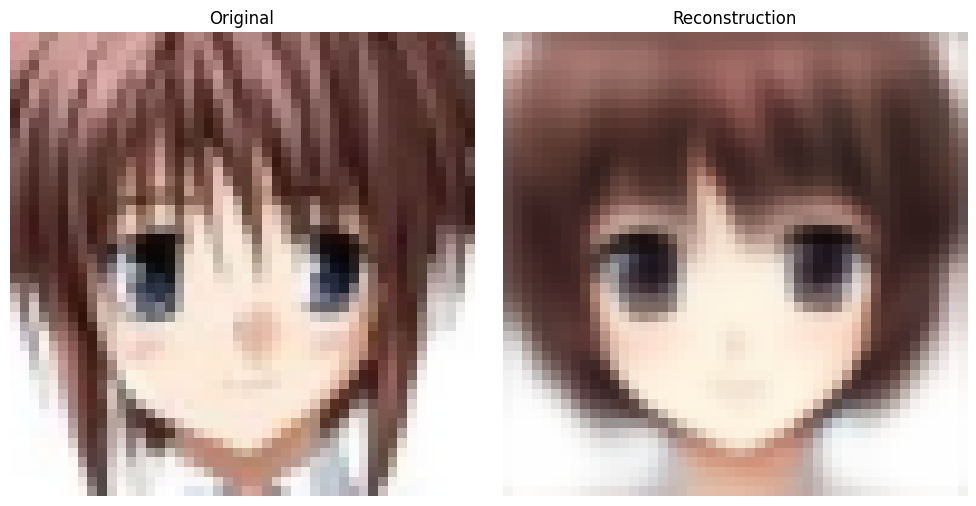

In [ ]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

def predict_single_image(image_path, model):
    # 1. Ensure image is loaded as RGB (3 channels)
    img = Image.open(image_path).convert('RGB')

    # 2. Use 'transform' (the variable you defined in Cell 3), NOT 'transforms' (the module)
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        # Get the reconstruction from the VAE
        reconstruction, mu, logvar = model(img_tensor)

    return img_tensor, reconstruction

def show_results(original, reconstructed):
    # 1. Squeeze to remove batch dim, move to CPU
    # 2. Permute from (C, H, W) to (H, W, C) so Matplotlib can read it
    orig_np = original.squeeze().permute(1, 2, 0).cpu().numpy()
    recon_np = reconstructed.squeeze().permute(1, 2, 0).cpu().numpy()

    # 3. Clip values to [0, 1] to prevent artifacting in visualization
    orig_np = orig_np.clip(0, 1)
    recon_np = recon_np.clip(0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot Original
    axes[0].imshow(orig_np)
    axes[0].set_title("Original")
    axes[0].axis('off')

    # Plot Reconstruction
    axes[1].imshow(recon_np)
    axes[1].set_title("Reconstruction")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the test
orig, recon = predict_single_image('./anime_faces/val/all/13631_2006.jpg', model)
show_results(orig, recon)

In [ ]:
import onnx

# 1. Match the latent_dim from your hyperparameters
latent_input = torch.randn(1, latent_dim).to(device)

# 2. Simplified Wrapper
class DecoderOnly(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        # Keep these as references to the original model layers
        self.decoder_input = full_model.decoder_input
        self.decoder = full_model.decoder

    def forward(self, z):
        # Apply the linear projection
        x = self.decoder_input(z)
        # The first layer of self.decoder is Unflatten,
        # so it handles the (256, 3, 3) conversion for us.
        return self.decoder(x)

# 3. Prepare model for export
decoder_model = DecoderOnly(model).to(device)
decoder_model.eval()

# 4. Export to ONNX
torch.onnx.export(
    decoder_model,
    latent_input,
    "decoder.onnx",
    export_params=True,        # Store trained weights inside the file
    opset_version=12,          # Standard version for web/frontend compatibility
    do_constant_folding=True,  # Optimization
    input_names=['latent_z'],  # Friendly name for your frontend sliders
    output_names=['reconstruction']
)

# 5. Optional: Verify and save
onnx_model = onnx.load("decoder.onnx")
onnx.checker.check_model(onnx_model)
onnx.save(onnx_model, "decoder.onnx")

print("ONNX export complete: decoder.onnx")

In [ ]:
!mv ./checkpoints/checkpoint.pth ./drive/MyDrive/checkpointv3.4.pth